# Fairness Partitioner POC

This notebook verifies the implementation of the `FairnessPartitioner`. 
We will load the Dutch Census dataset, partition it using the Fairness Partitioner, and visualize the resulting distributions.

In [6]:
import sys
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import Dataset
from collections import Counter

# Add src to path
# Assuming debugging from src/notebooks, we need to go up to src
sys.path.append(os.path.abspath(".."))

from FlowerFLTemplate.Datasets.Partitioner.fairness_partitioner import (
    FairnessPartitioner,
)

## 1. Load Dataset
We load the Dutch dataset and preprocess it slightly to match the expected format (binary sensitive, binary target).

In [7]:
# Path to dataset relative to src/notebooks
# Data is in src/puffle/examples/data/dutch_csv/dutch.csv
# So from notebooks, it is ../puffle/examples/data/dutch_csv/dutch.csv
DATA_PATH = "../puffle/examples/data/dutch_csv/dutch.csv"

df = pd.read_csv(DATA_PATH)

# Preprocessing (similar to legacy code)
# sex: 1, 2. Let's map 1->1, 2->0 (or check docs, assuming 1 is privileged male usually)
df["sex_binary"] = np.where(df["sex"] == 1, 1, 0)

# occupation: 21 (low?), 549 (high?).
# We use threshold 500 to separate them.
df["occupation_binary"] = np.where(df["occupation"] >= 500, 1, 0)


# Let's create a minimal DF for partitioning
df_proc = df[["sex", "occupation"]].copy()
df_proc["sex"] = df_proc["sex"].astype(int)
df_proc["occupation"] = df_proc["occupation"].astype(int)
df_proc["sex_bin"] = df["sex_binary"]
df_proc["occ_bin"] = df["occupation_binary"]

# Let's convert to HF Dataset
dataset = Dataset.from_pandas(df_proc)

print(f"Total samples: {len(df_proc)}")
print(df_proc.head())

Total samples: 60420
   sex  occupation  sex_bin  occ_bin
0    1          21        1        0
1    2         549        0        1
2    1          21        1        0
3    1         549        1        1
4    2         549        0        1


## 2. Partition Data
We configure the Fairness Partitioner.

In [8]:
NUM_PARTITIONS = 150
RATIO_UNFAIR = 0.5  # 5 unfair, 5 fair
SENSITIVE_BIN = "sex_bin"
TARGET_BIN = "occ_bin"

# Group to reduce: (target=1, sensitive=0) -> (1, 0)
GROUP_TO_REDUCE = (1, 0)
GROUP_TO_INCREMENT = (1, 1)

partitioner = FairnessPartitioner(
    num_partitions=NUM_PARTITIONS,
    sensitive_attribute=SENSITIVE_BIN,
    target_attribute=TARGET_BIN,
    ratio_unfair_clients=RATIO_UNFAIR,
    group_to_reduce=GROUP_TO_REDUCE,
    group_to_increment=GROUP_TO_INCREMENT,
    ratio_unfairness=(0.5, 0.7),
    seed=42,
    dataset=dataset,
)

partitioner.dataset = dataset  # Trigger partitioning

print(f"Discarded samples: {partitioner.discarded_samples_count}")

/home/lcorbucci/PUFFLE/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)
/home/lcorbucci/PUFFLE/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


Discarded samples: 5975


## 3. Visualize Distributions
We analyze the data distribution across clients using stacked bar charts for all groups.

All unique groups found: [(0, 0), (0, 1), (1, 0), (1, 1)]


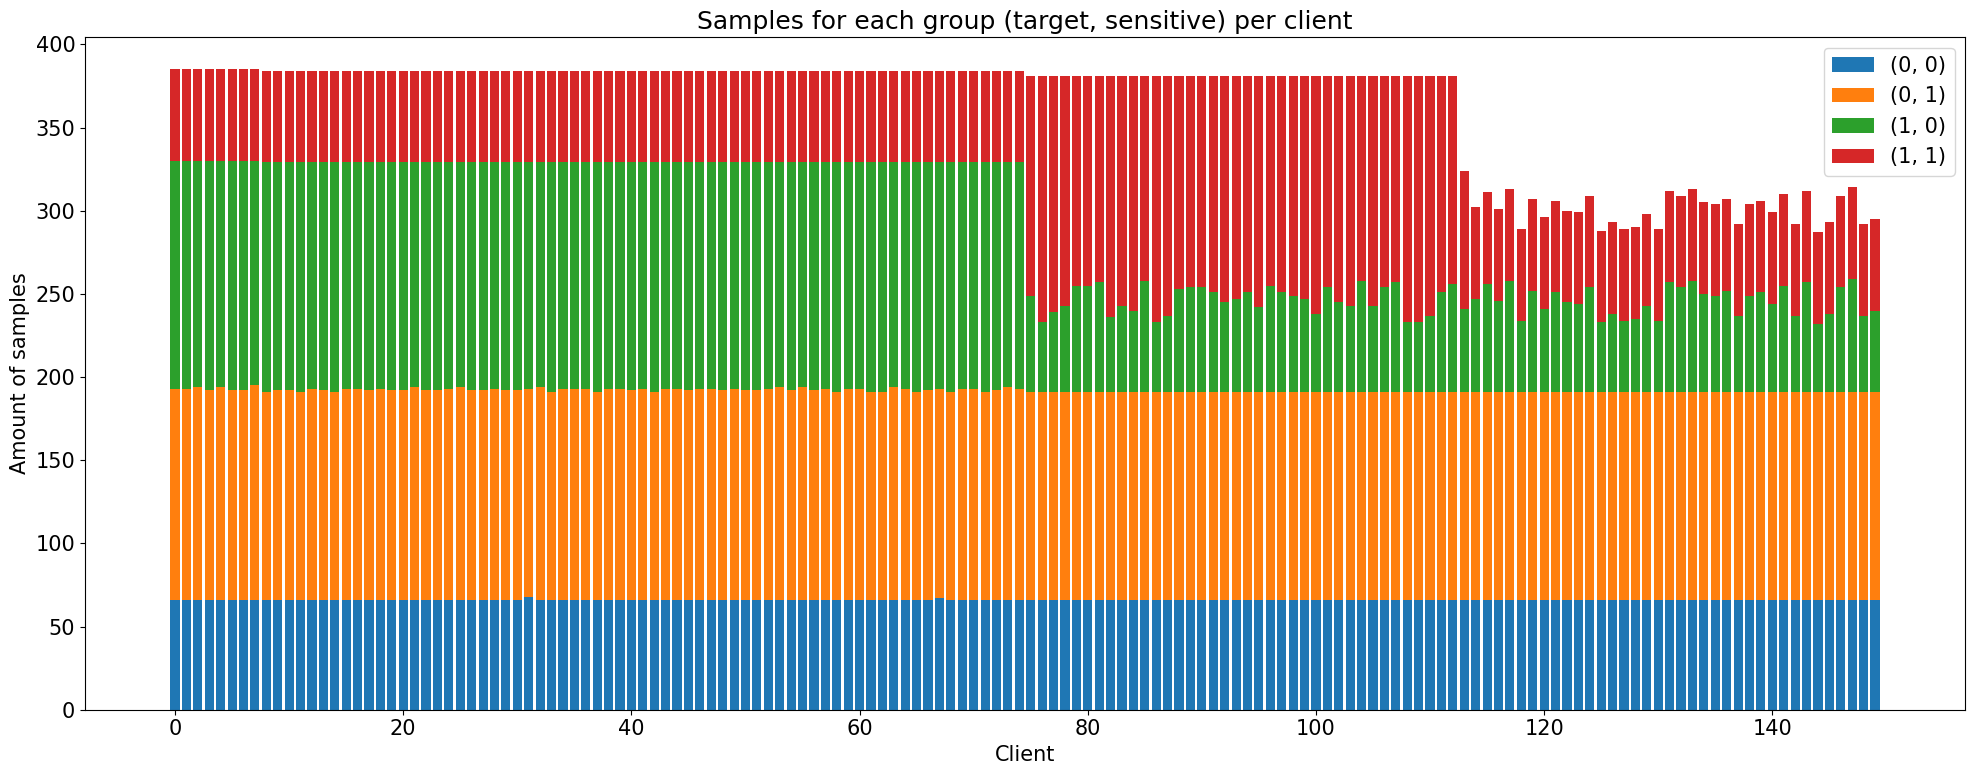

In [9]:
def plot_distributions(title: str, counter_groups: list, all_combinations: list):
    plt.figure(figsize=(20, 8))
    previous_sum = []

    # Iterate through each group combination (e.g. (0,0), (0,1), etc.)
    for combination in all_combinations:
        # Extract count for this combination for each client
        # counter_groups is a list of Counter objects (one per client)
        counter = [counter.get(combination, 0) for counter in counter_groups]

        if previous_sum:
            plt.bar(
                range(len(counter)),
                counter,
                bottom=previous_sum,
                label=str(combination),
            )
        else:
            plt.bar(range(len(counter)), counter, label=str(combination))
            previous_sum = [0] * len(counter)

        # Update previous_sum for stacking
        previous_sum = [sum(x) for x in zip(previous_sum, counter)]

    plt.xlabel("Client")
    plt.ylabel("Amount of samples")
    plt.title(title)
    plt.legend()
    plt.rcParams.update({"font.size": 15})
    plt.tight_layout()
    plt.show()


# 1. Collect counts per client
counter_groups = []
all_possible_groups = []

# Identify all possible groups from the dataset first (to ensure consistent coloring/order)
unique_groups = sorted(list(set(zip(df_proc[TARGET_BIN], df_proc[SENSITIVE_BIN]))))
print(f"All unique groups found: {unique_groups}")

for i in range(NUM_PARTITIONS):
    p_ds = partitioner.load_partition(i)
    df_p = p_ds.to_pandas()

    # Create a counter for this client: Key=(target, sensitive)
    # We can zip columns
    client_groups = list(zip(df_p[TARGET_BIN], df_p[SENSITIVE_BIN]))
    counter_groups.append(Counter(client_groups))

# 2. Plot
title = "Samples for each group (target, sensitive) per client"
plot_distributions(title, counter_groups, unique_groups)

## 4. Visualize Unfairness (Dataset Disparity)
We calculate and plot the **signed** Demographic Parity disparity for each client's dataset.
Disparity = $P(y=1 | z=0) - P(y=1 | z=1)$

- Positive value: Bias against z=1 (or towards z=0)
- Negative value: Bias against z=0 (or towards z=1)

   client_id  disparity  type
0          0   0.372679  fair
1          1   0.372679  fair
2          2   0.372721  fair
3          3   0.372603  fair
4          4   0.372721  fair


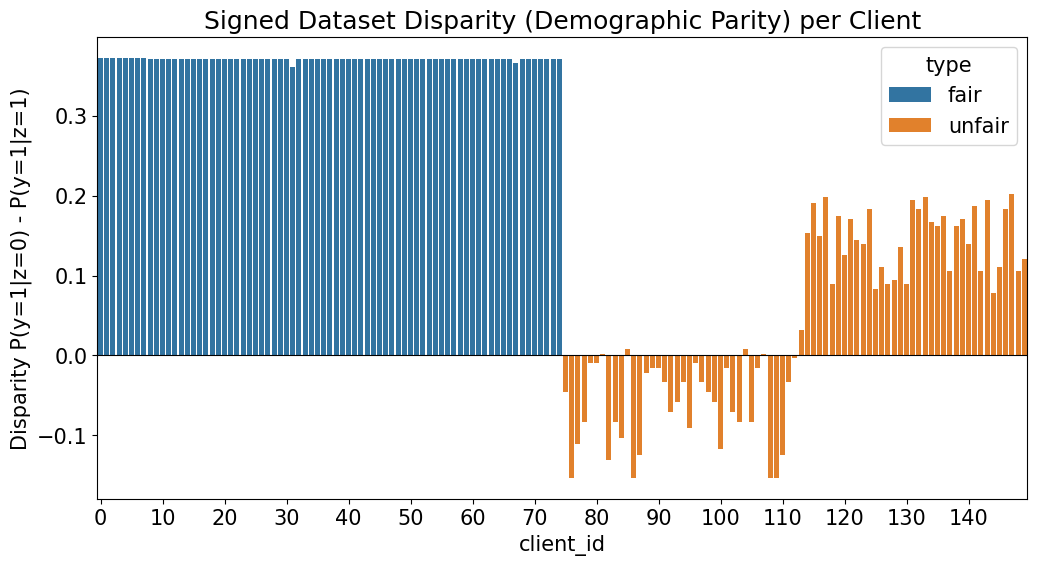

In [10]:
def compute_dataset_disparity(df, sensitive_col, target_col):
    # Disparity = P(y=1 | z=0) - P(y=1 | z=1)
    # Signed value indicates direction of unfairness.
    # Using Demographic Parity difference.

    # Calculate P(y=1 | z=0)
    df_z0 = df[df[sensitive_col] == 0]
    p_y1_z0 = df_z0[target_col].mean() if len(df_z0) > 0 else 0

    # Calculate P(y=1 | z=1)
    df_z1 = df[df[sensitive_col] == 1]
    p_y1_z1 = df_z1[target_col].mean() if len(df_z1) > 0 else 0

    return p_y1_z0 - p_y1_z1


client_disparities = []
client_ids = []
client_types = []

for i in range(NUM_PARTITIONS):
    p_ds = partitioner.load_partition(i)
    df_p = p_ds.to_pandas()

    disparity = compute_dataset_disparity(df_p, SENSITIVE_BIN, TARGET_BIN)
    client_disparities.append(disparity)
    client_ids.append(i)
    client_types.append(partitioner.client_types.get(i, "unknown"))

# Create DataFrame for plotting
disparity_df = pd.DataFrame(
    {"client_id": client_ids, "disparity": client_disparities, "type": client_types}
)

print(disparity_df.head())

plt.figure(figsize=(12, 6))
sns.barplot(data=disparity_df, x="client_id", y="disparity", hue="type", dodge=False)
plt.title("Signed Dataset Disparity (Demographic Parity) per Client")
plt.ylabel("Disparity P(y=1|z=0) - P(y=1|z=1)")
plt.axhline(0, color="black", linewidth=0.8)
# Simplify x-axis labels if too many
if NUM_PARTITIONS > 50:
    plt.xticks(ticks=range(0, NUM_PARTITIONS, 10), labels=range(0, NUM_PARTITIONS, 10))
plt.show()